# Schrödinger Bridge (SF2M) — Hold-One-Out Evaluation on the EB Dataset

Same LOO experiment as `2.01.05` (MIOFlow) and `2.01.06` (OT-CFM), using
**Schrödinger Bridge** (`SchrodingerBridgeConditionalFlowMatcher`, SF2M).

SF2M trains two models jointly:
- **Drift** (`sf2m_model`) — conditional flow (same role as in OT-CFM)
- **Score** (`sf2m_score_model`) — score function, penalises deviation from the SB path

Prediction uses the drift model alone (NeuralODE, Euler) for a deterministic trajectory —
identical integration strategy to 2.01.06.

Metrics (W1, MMD-G, MMD-M) are computed in **raw PCA space** (50D).

In [19]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import ot

sys.path.append('/Users/joaofelipe/Yale/Omics Toolbox/4_Code/MIOFlow_baselines/conditional-flow-matching')
from torchcfm.conditional_flow_matching import SchrodingerBridgeConditionalFlowMatcher
from torchcfm.models import MLP
from torchcfm.utils import torch_wrapper
from torchdyn.core import NeuralODE
from tqdm import tqdm

from mioflow import fit_gaga

## 1. Load Data

In [20]:
adata = sc.read_h5ad('data/scRNAseq/preprocessed_eb_adata.h5ad')
time_column = 'time_bin'
sorted_bins = sorted(adata.obs[time_column].unique())
print(adata)
print(f"Time bins: {sorted_bins}")

AnnData object with n_obs × n_vars = 16826 × 17845
    obs: 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'time_bin'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'pca', 'timepoint_colors'
    obsm: 'X_pca', 'X_phate'
    varm: 'PCs'
Time bins: [0.0, 1.0, 2.0, 3.0, 4.0]


## 2. Train GAGA (on all data)

In [21]:
gaga_model = fit_gaga(
    X_pca      = adata.obsm['X_pca'],
    X_phate    = adata.obsm['X_phate'],
    latent_dim = 2,
    hidden_dims= [128, 64],
    batch_size = 1024,
    encoder_epochs=300,
    decoder_epochs=300,
    learning_rate=1e-3,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cpu
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|██████████| 300/300 [01:23<00:00,  3.60it/s, train_loss=0.0061, recon=1.0115, dist=0.0061]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cpu
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|██████████| 300/300 [01:03<00:00,  4.76it/s, train_loss=0.7526, recon=0.7526, dist=0.0060]


### GAGA sanity check

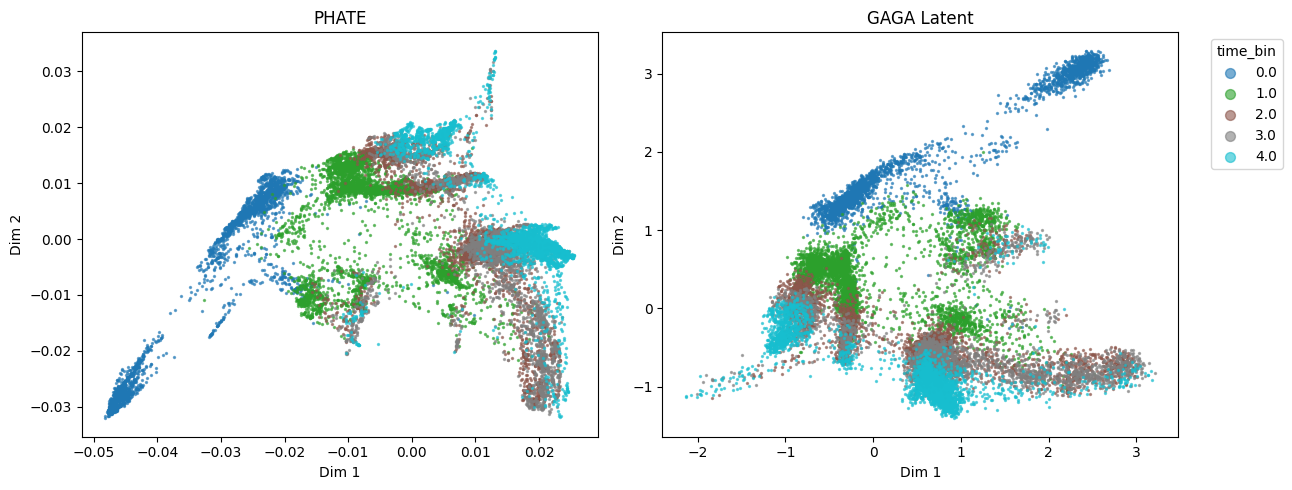

In [22]:
X_pca_all = adata.obsm['X_pca'].astype('float32')
X_pca_all_scaled = gaga_model.input_scaler.transform(X_pca_all)
gaga_model.eval()
with torch.no_grad():
    gaga_embeddings = gaga_model.encode(torch.tensor(X_pca_all_scaled)).numpy()
adata.obsm['X_gaga'] = gaga_embeddings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
categories = adata.obs[time_column].astype('category').cat
codes, cat_names = categories.codes.values, categories.categories
colors = plt.cm.tab10(np.linspace(0, 1, len(cat_names)))
for ax, key, title in zip(axes, ['X_phate', 'X_gaga'], ['PHATE', 'GAGA Latent']):
    for i, name in enumerate(cat_names):
        mask = codes == i
        ax.scatter(adata.obsm[key][mask, 0], adata.obsm[key][mask, 1],
                   color=colors[i], s=2, alpha=0.6, label=name)
    ax.set_title(title); ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
axes[-1].legend(title=time_column, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5)
plt.tight_layout(); plt.show()

## 3. SF2M helpers

### 3.1 Build training dataset for one LOO fold

In [23]:
def build_sb_dataset(adata_full, gaga_model, heldout_bin, time_column):
    """
    Encode all cells except heldout_bin into normalised GAGA 2D latent space.

    Returns X_list (one normalised 2D array per training timepoint),
    mean_, std_, and training_bins.
    """
    adata_train = adata_full[adata_full.obs[time_column] != heldout_bin]
    X_pca = adata_train.obsm['X_pca'].astype('float32')
    X_pca_scaled = gaga_model.input_scaler.transform(X_pca)
    gaga_model.eval()
    with torch.no_grad():
        X_gaga = gaga_model.encode(torch.tensor(X_pca_scaled)).numpy().astype('float32')

    mean_ = X_gaga.mean(axis=0)
    std_  = X_gaga.std(axis=0); std_[std_ == 0] = 1.0
    gaga_norm = ((X_gaga - mean_) / std_).astype('float32')

    training_bins = [b for b in sorted(adata_full.obs[time_column].unique()) if b != heldout_bin]
    time_labels = pd.factorize(adata_train.obs[time_column], sort=True)[0]
    X_list = [gaga_norm[time_labels == i] for i in range(len(training_bins))]
    return X_list, mean_, std_, training_bins

### 3.2 Training loop

In [24]:
def get_batch_sb(FM, X_list, batch_size, device):
    """Sample a training batch across all consecutive intervals."""
    ts, xts, uts, noises = [], [], [], []
    for t_start in range(len(X_list) - 1):
        i0 = np.random.choice(len(X_list[t_start]),     size=batch_size)
        i1 = np.random.choice(len(X_list[t_start + 1]), size=batch_size)
        x0 = torch.tensor(X_list[t_start][i0],     dtype=torch.float32, device=device)
        x1 = torch.tensor(X_list[t_start + 1][i1], dtype=torch.float32, device=device)
        t, xt, ut, eps = FM.sample_location_and_conditional_flow(x0, x1, return_noise=True)
        ts.append(t + t_start)
        xts.append(xt); uts.append(ut); noises.append(eps)
    return torch.cat(ts), torch.cat(xts), torch.cat(uts), torch.cat(noises)


def train_sb_fold(X_list, n_iters=10000, hidden_dim=64, sigma=0.1,
                  lr=1e-4, batch_size=128, device='cpu', verbose=False):
    """Train SF2M (drift + score) on X_list."""
    dim = X_list[0].shape[1]
    drift_model = MLP(dim=dim, time_varying=True, w=hidden_dim).to(device)
    score_model = MLP(dim=dim, time_varying=True, w=hidden_dim).to(device)
    optimizer = torch.optim.AdamW(
        list(drift_model.parameters()) + list(score_model.parameters()), lr=lr
    )
    FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)

    flow_losses, score_losses = [], []
    pbar = tqdm(range(n_iters), desc='SF2M', disable=not verbose)
    for i in pbar:
        optimizer.zero_grad()
        t, xt, ut, eps = get_batch_sb(FM, X_list, batch_size, device)
        lambda_t = FM.compute_lambda(t % 1)
        vt = drift_model(torch.cat([xt, t[:, None]], dim=-1))
        st = score_model(torch.cat([xt, t[:, None]], dim=-1))
        flow_loss  = torch.mean((vt - ut) ** 2)
        score_loss = torch.mean((lambda_t[:, None] * st + eps) ** 2)
        loss = flow_loss + score_loss
        loss.backward()
        optimizer.step()
        flow_losses.append(flow_loss.item())
        score_losses.append(score_loss.item())
        if verbose and i % 1000 == 0:
            pbar.set_postfix(flow=f'{flow_loss.item():.4f}', score=f'{score_loss.item():.4f}')

    return drift_model, score_model, flow_losses, score_losses

### 3.3 Prediction at held-out timepoint

In [30]:
def predict_at_heldout_sb(drift_model, X_list, mean_, std_,
                           adata_full, gaga_model, heldout_bin,
                           time_column, device='cpu', n_steps=200,
                           n_trajectories=None, seed=42):
    """
    Integrate SF2M drift from label_prev → t_label_heldout in GAGA 2D space.

    Returns
    -------
    pred_latent : (n, 2)  — predicted GAGA 2D positions (for metrics + visualisation)
    true_latent : (m, 2)  — ground-truth GAGA 2D positions (for metrics + visualisation)
    """
    all_bins = sorted(adata_full.obs[time_column].unique())
    heldout_idx = all_bins.index(heldout_bin)
    t_prev = all_bins[heldout_idx - 1]
    t_next = all_bins[heldout_idx + 1]

    frac = (heldout_bin - t_prev) / (t_next - t_prev)
    training_bins = [b for b in all_bins if b != heldout_bin]
    label_prev      = float(training_bins.index(t_prev))
    label_next      = float(training_bins.index(t_next))
    t_label_heldout = label_prev + frac * (label_next - label_prev)

    X_prev_arr = X_list[int(label_prev)]
    if n_trajectories is not None and n_trajectories < len(X_prev_arr):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X_prev_arr), size=n_trajectories, replace=False)
        X_prev_arr = X_prev_arr[idx]
    X_prev = torch.tensor(X_prev_arr, dtype=torch.float32)
    t_span = torch.linspace(label_prev, t_label_heldout, n_steps)

    node = NeuralODE(torch_wrapper(drift_model), solver='euler', sensitivity='adjoint')
    drift_model.eval()
    with torch.no_grad():
        traj = node.trajectory(X_prev.to(device), t_span=t_span.to(device)).cpu()

    pred_latent = (traj[-1].numpy() * std_ + mean_).astype('float32')  # denormalise → GAGA 2D

    # Ground truth: encode PCA → GAGA 2D
    mask_held = adata_full.obs[time_column] == heldout_bin
    X_pca_held = adata_full.obsm['X_pca'][mask_held.values].astype('float32')
    X_pca_held_scaled = gaga_model.input_scaler.transform(X_pca_held)
    gaga_model.eval()
    with torch.no_grad():
        true_latent = gaga_model.encode(torch.tensor(X_pca_held_scaled)).numpy().astype('float32')

    return pred_latent, true_latent

## 4. Evaluation metrics (PCA space — identical to 2.01.05 and 2.01.06)

In [25]:
def wasserstein1(X, Y, n_sample=1000, seed=42):
    rng = np.random.default_rng(seed)
    ix = rng.choice(len(X), size=min(n_sample, len(X)), replace=False)
    iy = rng.choice(len(Y), size=min(n_sample, len(Y)), replace=False)
    Xs, Ys = X[ix], Y[iy]
    M = ot.dist(Xs, Ys, metric='euclidean')
    return float(ot.emd2(ot.unif(len(Xs)), ot.unif(len(Ys)), M))

def _gaussian_kernel(X, Y, sigma):
    sq = np.sum((X[:, None] - Y[None]) ** 2, axis=-1)
    return np.exp(-sq / (2 * sigma ** 2))

def mmd_gaussian(X, Y):
    XY = np.vstack([X, Y])
    M  = ot.dist(XY, XY, metric='euclidean')
    sigma = float(np.median(M[M > 0])) or 1.0
    return float(_gaussian_kernel(X,X,sigma).mean()
                 + _gaussian_kernel(Y,Y,sigma).mean()
                 - 2*_gaussian_kernel(X,Y,sigma).mean())

def mmd_mean(X, Y):
    return float(np.linalg.norm(X.mean(axis=0) - Y.mean(axis=0)))

def compute_metrics(pred_pca, true_pca):
    return {'W1': wasserstein1(pred_pca, true_pca),
            'MMD_G': mmd_gaussian(pred_pca, true_pca),
            'MMD_M': mmd_mean(pred_pca, true_pca)}

print("Metric functions ready.")

Metric functions ready.


## 5. Focal experiment — hold out timepoint 2

In [26]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FOCAL_BIN = sorted_bins[1]
print(f"Holding out time bin: {FOCAL_BIN}  |  device: {DEVICE}")

X_list_focal, mean_focal, std_focal, training_bins_focal = build_sb_dataset(
    adata, gaga_model, FOCAL_BIN, time_column
)
print(f"Training bins: {training_bins_focal}")
print(f"GAGA 2D dims: {X_list_focal[0].shape[1]}  |  Cells per bin: {[len(x) for x in X_list_focal]}")

Holding out time bin: 1.0  |  device: cpu
Training bins: [0.0, 2.0, 3.0, 4.0]
GAGA 2D dims: 2  |  Cells per bin: [2381, 3279, 3668, 3333]


SF2M: 100%|██████████| 10000/10000 [01:01<00:00, 163.33it/s, flow=0.1521, score=1.0155]


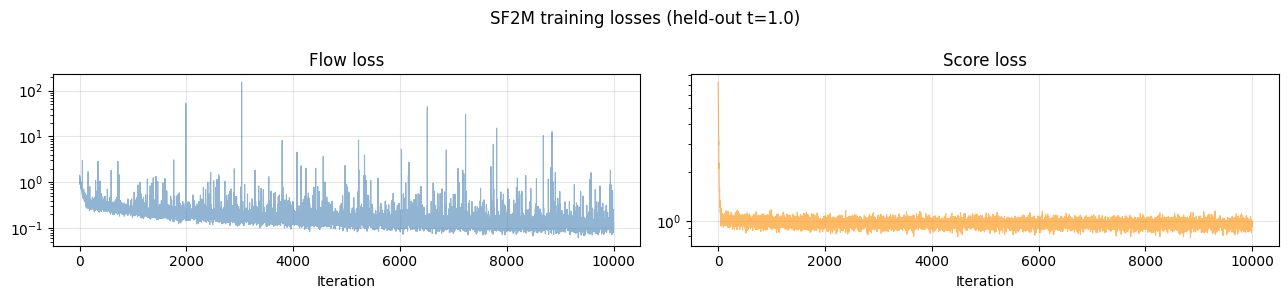

In [27]:
drift_focal, score_focal, flow_losses_focal, score_losses_focal = train_sb_fold(
    X_list_focal, n_iters=10000, hidden_dim=64, sigma=0.1,
    lr=1e-4, batch_size=128, device=DEVICE, verbose=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(flow_losses_focal,  alpha=0.6, linewidth=0.8, color='steelblue')
axes[0].set_title('Flow loss'); axes[0].set_yscale('log')
axes[1].plot(score_losses_focal, alpha=0.6, linewidth=0.8, color='darkorange')
axes[1].set_title('Score loss'); axes[1].set_yscale('log')
for ax in axes:
    ax.set_xlabel('Iteration'); ax.grid(True, alpha=0.3)
plt.suptitle(f'SF2M training losses (held-out t={FOCAL_BIN})', fontsize=12)
plt.tight_layout(); plt.show()

In [31]:
pred_focal_latent, true_focal_latent = predict_at_heldout_sb(
    drift_focal, X_list_focal, mean_focal, std_focal,
    adata, gaga_model, FOCAL_BIN, time_column, device=DEVICE,
    n_trajectories=100,
)
print(f"Predicted  — latent: {pred_focal_latent.shape}")
print(f"Ground truth — latent: {true_focal_latent.shape}")

Predicted  — latent: (100, 2)
Ground truth — latent: (4165, 2)


### 5.1 Interpolation plot — predicted vs. ground truth at timepoint 2

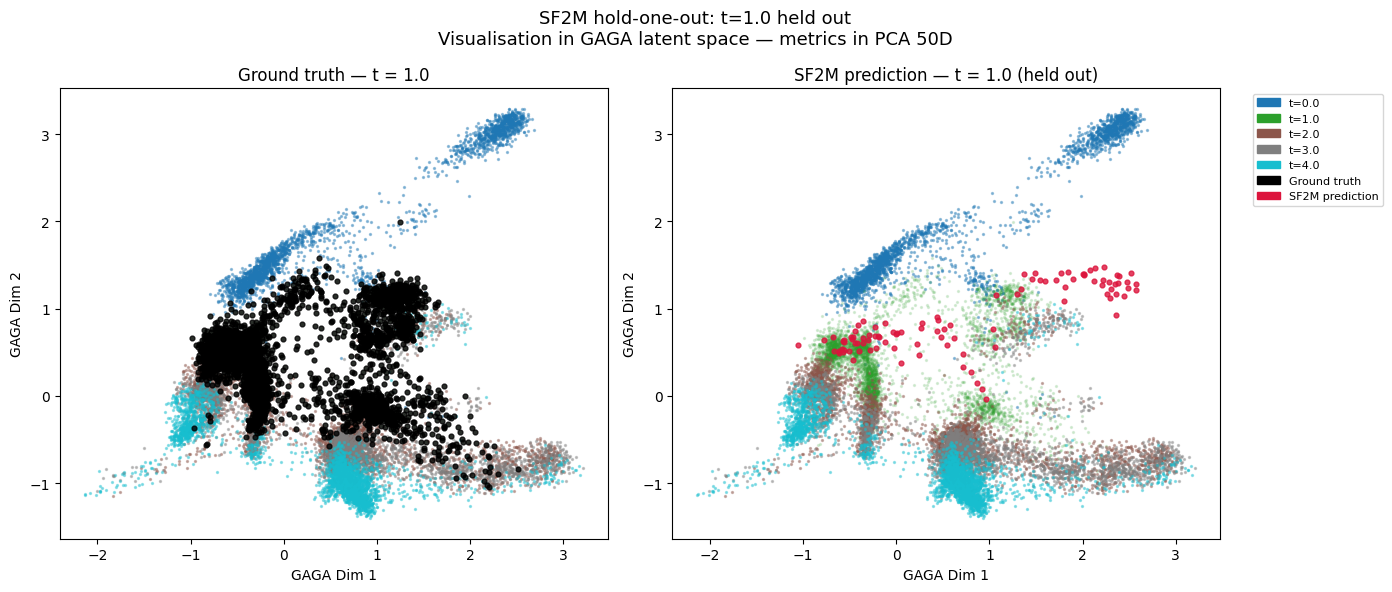

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(sorted_bins)))

for ax in axes:
    for i, tb in enumerate(sorted_bins):
        mask = adata.obs[time_column] == tb
        alpha = 0.15 if tb == FOCAL_BIN else 0.4
        ax.scatter(adata.obsm['X_gaga'][mask, 0], adata.obsm['X_gaga'][mask, 1],
                   color=palette[i], s=2, alpha=alpha, rasterized=True)

axes[0].scatter(true_focal_latent[:, 0], true_focal_latent[:, 1],
                color='black', s=12, alpha=0.8, zorder=5)
axes[0].set_title(f'Ground truth — t = {FOCAL_BIN}')
axes[0].set_xlabel('GAGA Dim 1'); axes[0].set_ylabel('GAGA Dim 2')

axes[1].scatter(pred_focal_latent[:, 0], pred_focal_latent[:, 1],
                color='crimson', s=12, alpha=0.8, zorder=5)
axes[1].set_title(f'SF2M prediction — t = {FOCAL_BIN} (held out)')
axes[1].set_xlabel('GAGA Dim 1'); axes[1].set_ylabel('GAGA Dim 2')

handles = [mpatches.Patch(color=palette[i], label=f't={tb}') for i, tb in enumerate(sorted_bins)]
handles += [mpatches.Patch(color='black',   label='Ground truth'),
            mpatches.Patch(color='crimson',  label='SF2M prediction')]
axes[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.suptitle(f'SF2M hold-one-out: t={FOCAL_BIN} held out\n'
             'Visualisation in GAGA latent space — metrics in PCA 50D', fontsize=13)
plt.tight_layout(); plt.show()

### 5.2 Metrics for held-out timepoint 2

In [33]:
metrics_focal = compute_metrics(pred_focal_latent, true_focal_latent)
df_focal = pd.DataFrame([{'Held-out t': FOCAL_BIN, **metrics_focal}])
print(df_focal.to_string(index=False))
df_focal

 Held-out t       W1    MMD_G   MMD_M
        1.0 0.869422 0.154038 0.84279


,Held-out t,W1,MMD_G,MMD_M
0,1.0,0.869422,0.154038,0.84279


## 6. Full Leave-One-Out Table

In [34]:
N_TRAJ = 100  # fixed seed population for comparability across methods

loo_results = []

for heldout_bin in sorted_bins[1:-1]:
    print(f"\n{'='*50}\n  LOO fold: t={heldout_bin}\n{'='*50}")

    if heldout_bin == FOCAL_BIN:
        pred_latent, true_latent = pred_focal_latent, true_focal_latent
    else:
        X_list, mean_, std_, _ = build_sb_dataset(adata, gaga_model, heldout_bin, time_column)
        drift_model, _, _, _ = train_sb_fold(
            X_list, n_iters=10000, hidden_dim=64, sigma=0.1,
            lr=1e-4, batch_size=128, device=DEVICE, verbose=False,
        )
        pred_latent, true_latent = predict_at_heldout_sb(
            drift_model, X_list, mean_, std_,
            adata, gaga_model, heldout_bin, time_column, device=DEVICE,
            n_trajectories=N_TRAJ,
        )

    metrics = compute_metrics(pred_latent, true_latent)
    loo_results.append({'t': heldout_bin, **metrics})
    print(f"  W1={metrics['W1']:.4f}  MMD-G={metrics['MMD_G']:.4f}  MMD-M={metrics['MMD_M']:.4f}")

df_loo = pd.DataFrame(loo_results)
print("\nDone.")
df_loo


  LOO fold: t=1.0
  W1=0.8694  MMD-G=0.1540  MMD-M=0.8428

  LOO fold: t=2.0
  W1=0.4864  MMD-G=0.0356  MMD-M=0.2501

  LOO fold: t=3.0
  W1=0.4667  MMD-G=0.0316  MMD-M=0.4448

Done.


,t,W1,MMD_G,MMD_M
0,1.0,0.869422,0.154038,0.842790
1,2.0,0.486426,0.035626,0.250068
2,3.0,0.466747,0.031649,0.444784


### Summary table — LOO W1 and MMD (SF2M, α-decay kernel)

In [35]:
df_display = df_loo.copy()
df_display.columns = ['Held-out t', 'W1', 'MMD (G)', 'MMD (M)']
df_display = df_display.set_index('Held-out t')
df_display.loc['Mean'] = df_display.mean()

df_display.style \
    .format('{:.4f}') \
    .set_caption('Leave-one-out W1 and MMD — SF2M (EB dataset, α-decay kernel)') \
    .highlight_min(color='#d4efdf', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :]) \
    .highlight_max(color='#fadbd8', axis=0, subset=pd.IndexSlice[df_display.index[:-1], :])

,W1,MMD (G),MMD (M)
Held-out t,,,
1.000000,0.8694,0.1540,0.8428
2.000000,0.4864,0.0356,0.2501
3.000000,0.4667,0.0316,0.4448
Mean,0.6075,0.0738,0.5125


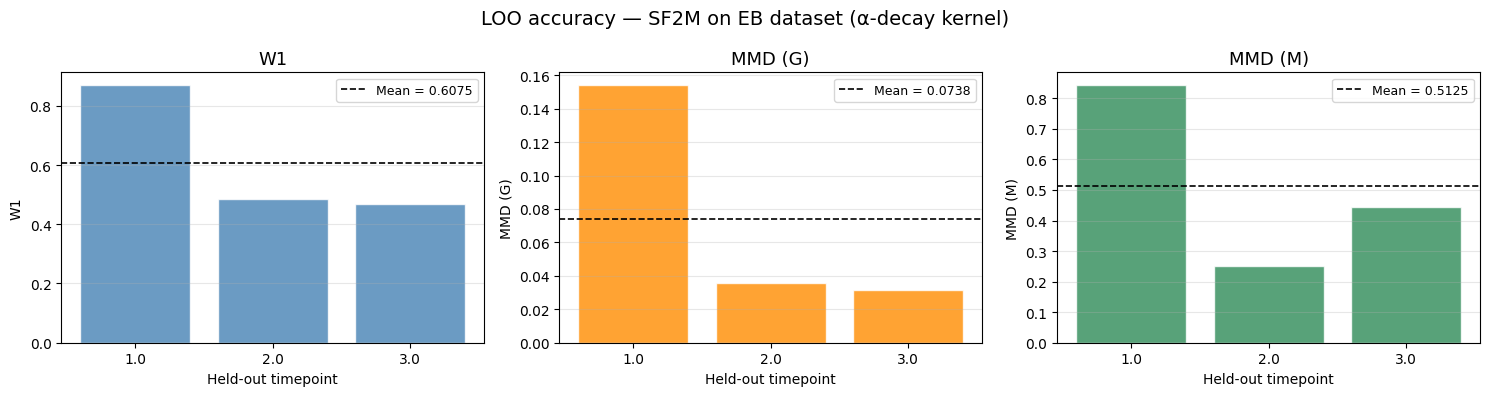

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, col, label, color in zip(
    axes,
    ['W1', 'MMD_G', 'MMD_M'],
    ['W1', 'MMD (G)', 'MMD (M)'],
    ['steelblue', 'darkorange', 'seagreen'],
):
    vals = df_loo[col].values
    ts   = df_loo['t'].astype(str).values
    ax.bar(ts, vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Held-out timepoint')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('LOO accuracy — SF2M on EB dataset (α-decay kernel)', fontsize=14)
plt.tight_layout()
plt.show()